In [ ]:
pip install xarray netcdf4 rioxarray matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
et = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Evapotranspiration/GLEAM_Evapotranspiration_resampled_NN.nc")
sm = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Soil Moisture/SoilMoisture_Crop.nc")
ro = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Runoff/Runoff_cropped_resampled.nc")
gw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Groundwater/PENINSULAR_INDIA_GLDAS_GWS_cm_Monthly_2003_2024.nc")
precip = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Precipitation/Rainfall_Resample_Cropped.nc")

print(et)
print(sm)
print(ro)
print(gw)
print(precip)

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 300, lat: 67, lon: 75)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2000-01-31 2000-02-29 ... 2024-12-31
  * lat          (lat) float64 536B 8.15 8.4 8.65 8.9 ... 23.9 24.15 24.4 24.65
  * lon          (lon) float64 600B 72.55 72.8 73.05 73.3 ... 90.55 90.8 91.05
Data variables:
    spatial_ref  int64 8B ...
    ET           (time, lat, lon) float32 6MB ...
<xarray.Dataset> Size: 6MB
Dimensions:      (time: 300, lat: 67, lon: 75)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2024-12-01
  * lat          (lat) float32 268B 24.62 24.38 24.12 ... 8.625 8.375 8.125
  * lon          (lon) float32 300B 72.62 72.88 73.12 ... 90.62 90.88 91.12
Data variables:
    spatial_ref  int64 8B ...
    sm           (time, lat, lon) float32 6MB ...
<xarray.Dataset> Size: 6MB
Dimensions:      (valid_time: 300, latitude: 67, longitude: 73)
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 2kB 2000-01-01

In [ ]:
et_var = et['ET']
print("Evapotranspiration", et.data_vars)
print('Unit :', et['ET'].attrs.get('units'))

sm_var = sm['sm']
print("Soil Moisture", sm.data_vars)
print('Unit: ',sm['sm'].attrs.get('units'))

ro_var = ro['ro']
print("Run Off", ro.data_vars)
print('Unit: ',ro['ro'].attrs.get('units'))

gw_var = gw['GWS_tavg']
print("Groundwater", gw.data_vars)
print('Unit: ',gw['GWS_tavg'].attrs.get('units'))

precip_var = precip['satellite_precip']
print("Precipitation", precip.data_vars)
print('Unit: ',precip['satellite_precip'].attrs.get('units'))

Evapotranspiration Data variables:
    spatial_ref  int64 8B ...
    ET           (time, lat, lon) float32 6MB ...
Unit : mm.month-1
Soil Moisture Data variables:
    spatial_ref  int64 8B ...
    sm           (time, lat, lon) float32 6MB ...
Unit:  m3 m-3
Run Off Data variables:
    spatial_ref  int64 8B ...
    ro           (valid_time, latitude, longitude) float32 6MB ...
Unit:  m
Groundwater Data variables:
    spatial_ref  int64 8B ...
    GWS_tavg     (time, lat, lon) float32 5MB ...
Unit:  cm
Precipitation Data variables:
    spatial_ref       int64 8B ...
    satellite_precip  (time, lat, lon) float32 6MB ...
Unit:  mm/day


In [ ]:
et_ts = et_var.mean(dim=['lat','lon'])
sm_ts = sm_var.mean(dim=['lat','lon'])
ro_ts = ro_var.mean(dim=['latitude','longitude'])
gw_ts = gw_var.mean(dim=['lat','lon'])
precip_ts = precip_var.mean(dim=['lat','lon'])

In [ ]:
et_ts['time'] = et_ts.indexes['time'].to_period('M').to_timestamp()
sm_ts['time'] = sm_ts.indexes['time'].to_period('M').to_timestamp()
ro_ts['valid_time'] = ro_ts.indexes['valid_time'].to_period('M').to_timestamp()
gw_ts['time'] = gw_ts.indexes['time'].to_period('M').to_timestamp()
precip_ts['time'] = precip_ts.indexes['time'].to_period('M').to_timestamp()

In [ ]:
et_df = et_ts.to_dataframe(name="ET")
sm_df = sm_ts.to_dataframe(name="SoilMoisture")
ro_df = ro_ts.to_dataframe(name="Runoff")
gw_df = gw_ts.to_dataframe(name="Groundwater")
precip_df = precip_ts.to_dataframe(name="Precipitation")

In [ ]:
df = et_df.join(sm_df).join(ro_df).join(gw_df).join(precip_df)

In [ ]:
print(df.head())
print(df.isna().sum())

                   ET  SoilMoisture  number expver    Runoff  Groundwater  \
time                                                                        
2000-01-01  92.037544      0.180075       0   0001  0.000154          NaN   
2000-02-01  71.600471      0.173777       0   0001  0.000119          NaN   
2000-03-01  77.452751      0.150487       0   0001  0.000070          NaN   
2000-04-01  72.075317      0.158713       0   0001  0.000101          NaN   
2000-05-01  95.407433      0.197286       0   0001  0.000160          NaN   

            Precipitation  
time                       
2000-01-01       0.417386  
2000-02-01       0.942211  
2000-03-01       0.322670  
2000-04-01       1.276997  
2000-05-01       3.139652  
ET                0
SoilMoisture      0
number            0
expver            0
Runoff            0
Groundwater      37
Precipitation     3
dtype: int64


In [ ]:
df = df.loc["2003":"2024"]

In [ ]:
df_clean = df.dropna()
print(df_clean.shape)

(260, 7)


In [ ]:
df_mod = df_clean[['ET','SoilMoisture','Runoff','Groundwater','Precipitation']]
df_mod.head()

,ET,SoilMoisture,Runoff,Groundwater,Precipitation
time,,,,,
2003-02-01,63.154705,0.158239,0.000079,71.080688,1.220255
2003-03-01,68.150124,0.152406,0.000073,70.795517,1.040656
2003-04-01,67.660126,0.151886,0.000086,69.262650,1.437548
2003-05-01,58.156895,0.155351,0.000079,67.845551,1.322017
2003-06-01,81.745041,0.239225,0.000898,68.215256,5.368516


In [ ]:
corr_matrix = df_mod.corr()
print(corr_matrix)

                     ET  SoilMoisture    Runoff  Groundwater  Precipitation
ET             1.000000      0.721384  0.507022     0.696089       0.410345
SoilMoisture   0.721384      1.000000  0.893920     0.630667       0.837054
Runoff         0.507022      0.893920  1.000000     0.531135       0.849480
Groundwater    0.696089      0.630667  0.531135     1.000000       0.159781
Precipitation  0.410345      0.837054  0.849480     0.159781       1.000000


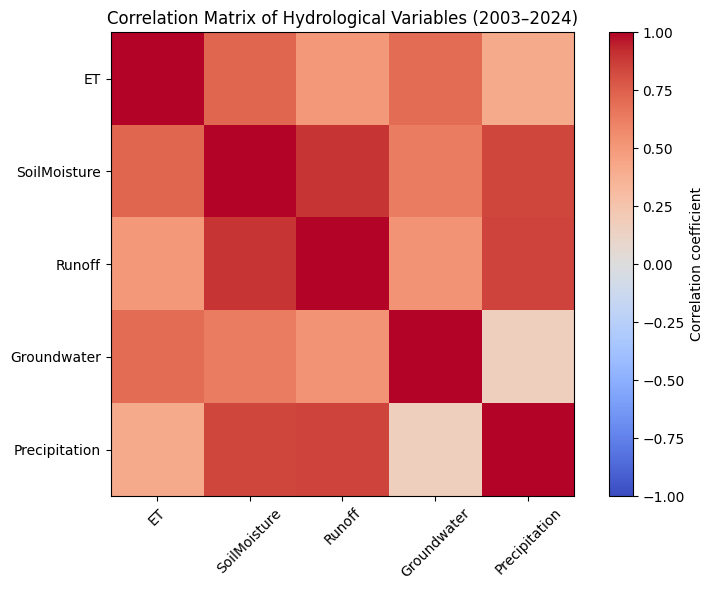

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

plt.title("Correlation Matrix of Hydrological Variables (2003–2024)")

plt.tight_layout()
plt.show()

In [ ]:
def remove_seasonality(df):
    """
    Remove seasonal cycle using monthly climatology.
    Returns anomaly dataframe.
    """
    monthly_mean = df.groupby(df.index.month).transform("mean")
    anomalies = df - monthly_mean
    return anomalies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def lag_correlation(series1, series2, max_lag=12, title="Lag Correlation"):

    lags = np.arange(-max_lag, max_lag+1)
    corr_vals = []

    for lag in lags:
        corr = series1.corr(series2.shift(lag))
        corr_vals.append(corr)

    plt.figure(figsize=(8,5))
    plt.plot(lags, corr_vals, marker='o')

    plt.title(title)
    plt.xlabel("Lag (Months)")
    plt.ylabel("Correlation")
    plt.grid(True)

    plt.show()

    return lags, corr_vals

In [ ]:
df_anom = remove_seasonality(df_mod)

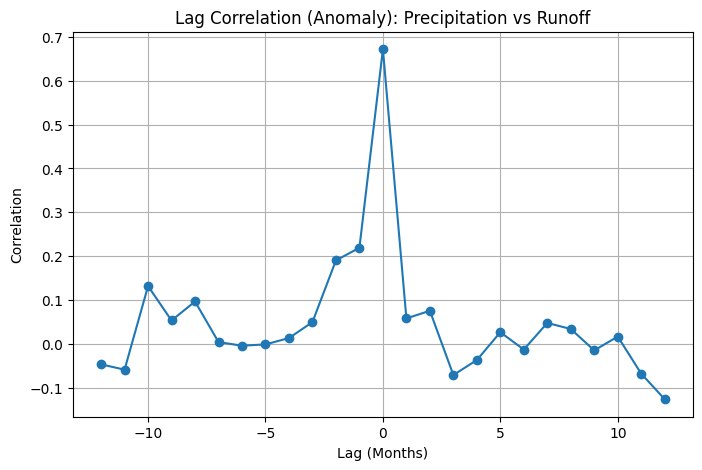

(array([-12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,
          1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12]),
 [np.float64(-0.04720189573774595),
  np.float64(-0.05923632647147041),
  np.float64(0.13144949266600606),
  np.float64(0.05299476695640177),
  np.float64(0.09636217196617733),
  np.float64(0.0037578700063347656),
  np.float64(-0.0045811923752328365),
  np.float64(-0.0015962384599467827),
  np.float64(0.012861758499293887),
  np.float64(0.04930388185379604),
  np.float64(0.19020006141773407),
  np.float64(0.21895187157847004),
  np.float64(0.6722199522035665),
  np.float64(0.05772129495830468),
  np.float64(0.07517235204090607),
  np.float64(-0.07150714713012962),
  np.float64(-0.03730263909672244),
  np.float64(0.026188219893058865),
  np.float64(-0.013360536640011628),
  np.float64(0.04742247167616759),
  np.float64(0.03355784037322243),
  np.float64(-0.015332933140269211),
  np.float64(0.01633445588942071),
  np.float64(-0.06846222217122461),

In [ ]:
lag_correlation(
    df_anom["Precipitation"],
    df_anom["Runoff"],
    title="Lag Correlation (Anomaly): Precipitation vs Runoff"
)

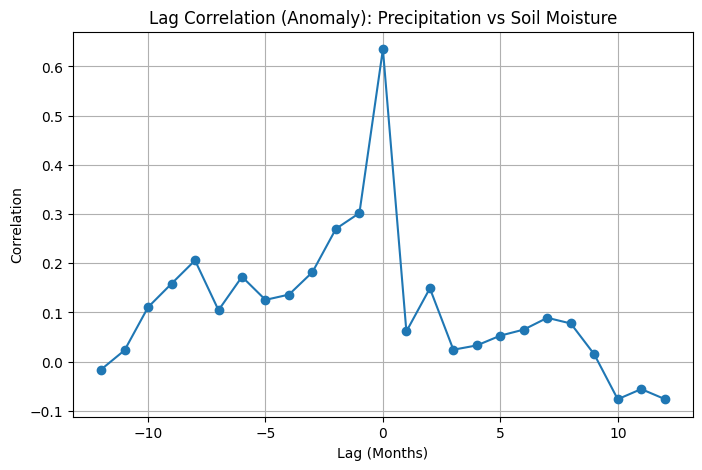

(array([-12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,
          1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12]),
 [np.float64(-0.016129820865405178),
  np.float64(0.023057050889840724),
  np.float64(0.11055973900406263),
  np.float64(0.15842762913742922),
  np.float64(0.2057346723113804),
  np.float64(0.10455969351348741),
  np.float64(0.17253470347811908),
  np.float64(0.12549783055524336),
  np.float64(0.13622242018905262),
  np.float64(0.18189886733746935),
  np.float64(0.2699278539971816),
  np.float64(0.3019810021204856),
  np.float64(0.6349530455239148),
  np.float64(0.06128324781706774),
  np.float64(0.14895475439596723),
  np.float64(0.02419733251581928),
  np.float64(0.03291813810479629),
  np.float64(0.052792083472846356),
  np.float64(0.06510130235525993),
  np.float64(0.08903954894056564),
  np.float64(0.07753024369239456),
  np.float64(0.014769707498779152),
  np.float64(-0.07644747728753895),
  np.float64(-0.05580479733519041),
  np.float64(-

In [ ]:
lag_correlation(
    df_anom["Precipitation"],
    df_anom["SoilMoisture"],
    title="Lag Correlation (Anomaly): Precipitation vs Soil Moisture"
)

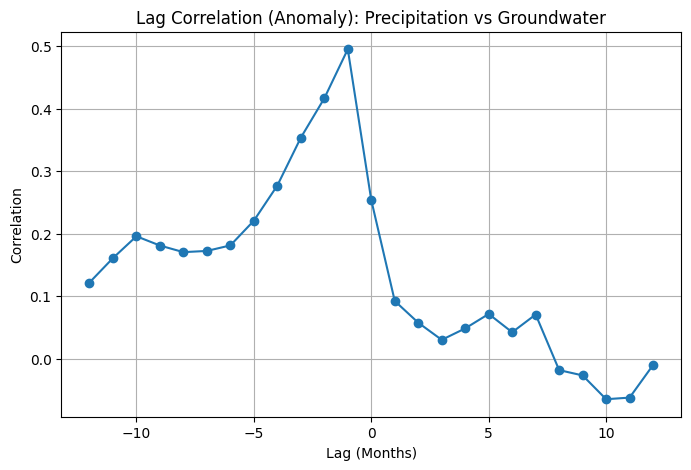

(array([-12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,
          1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12]),
 [np.float64(0.12180662606801533),
  np.float64(0.16085479798338465),
  np.float64(0.19578484193502096),
  np.float64(0.18098773025894888),
  np.float64(0.17040379193141986),
  np.float64(0.17232959256072317),
  np.float64(0.18119168378242637),
  np.float64(0.2206753950716564),
  np.float64(0.27693326271595653),
  np.float64(0.35344470730416355),
  np.float64(0.41638244330887353),
  np.float64(0.4949085127370662),
  np.float64(0.2536437762891838),
  np.float64(0.0923041119447493),
  np.float64(0.057561687193505226),
  np.float64(0.030142704402860244),
  np.float64(0.048460688079101956),
  np.float64(0.07154404533079686),
  np.float64(0.04229129276890195),
  np.float64(0.07065350558058887),
  np.float64(-0.018274601009503986),
  np.float64(-0.026744649682770762),
  np.float64(-0.06480590562976946),
  np.float64(-0.062212009038505364),
  np.float6

In [ ]:
lag_correlation(
    df_anom["Precipitation"],
    df_anom["Groundwater"],
    title="Lag Correlation (Anomaly): Precipitation vs Groundwater"
)

In [ ]:
import seaborn as sns

def lag_heatmap(df, reference_var, max_lag=12):

    lags = range(-max_lag, max_lag+1)
    variables = df.columns

    corr_matrix = []

    for var in variables:
        row = []
        for lag in lags:
            row.append(df[reference_var].corr(df[var].shift(lag)))
        corr_matrix.append(row)

    plt.figure(figsize=(10,6))

    sns.heatmap(
        corr_matrix,
        xticklabels=lags,
        yticklabels=variables,
        cmap="coolwarm",
        center=0
    )

    plt.title(f"Lag Correlation Heatmap (Reference: {reference_var})")
    plt.xlabel("Lag (Months)")
    plt.ylabel("Variables")

    plt.show()

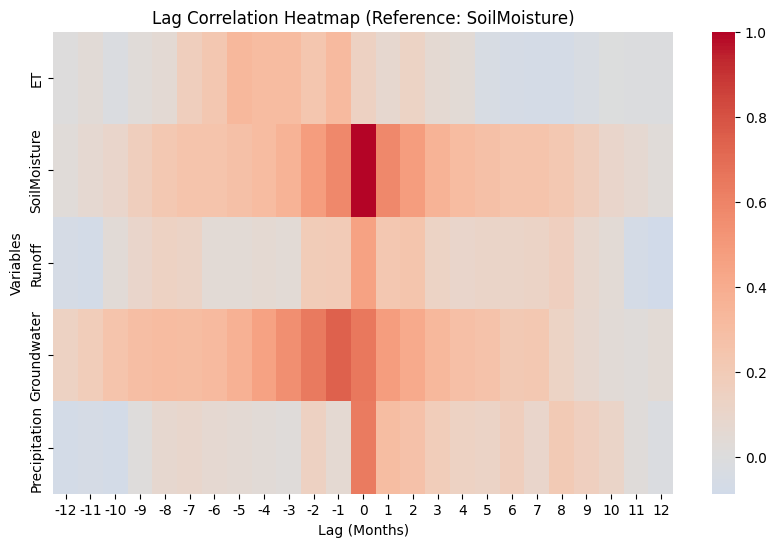

In [ ]:
lag_heatmap(df_anom, "SoilMoisture")